У цьому ноутбуці буде згенеровано тектовий опис для зображення, що міститься в кожному твіттер-повідомленні даного датасету. З опису набору даних відомо, що з кожного зображення попередньо було розпізнано текст, який міститься на зображенні, проте текст наявний не на всіх екземплярах. Екстракція тексту з картинок проводилась методом OCR і виконувалась авторами, що збирали дані.

Текстовий опис зображення (caption) згенеровано за допомогою моделі BLIP (Bootstrapped Language-Image Pretraining) через платформу Hugging Face. Ця модель здатна генерувати текстовий опис картинок, а також видаляти з описів шум, що підвищує якість такого тексту. Генерація описів проводилась для всіх наявних спостережень без розділення їх на тренувальні, валідаційні та тестувальні.

In [1]:
# Imports
from google.colab import drive
import os
import sys
import shutil
import pandas as pd
from tqdm import tqdm # add a visual progress bar to loops
import zipfile
from PIL import Image

In [2]:
# Remove limit for diplaying columns
pd.set_option('display.max_colwidth', None)

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path to Google Drive project directory
drive_project_dir = '/content/drive/MyDrive/twitter-multimodal-hate-speech-classifier'

# Set project directory as current working directory
os.chdir(drive_project_dir)

# Set path to directory for data files in Google Drive
drive_data_dir = 'data' # relative path
os.makedirs(drive_data_dir, exist_ok=True)

In [5]:
# Setup paths to considered files

# Primary dataset given by authors with minor preliminary handling (Step 0: added timestamp and texts from images)
raw_data_parquet = os.path.join (drive_data_dir, 'twitter_data_with_text_from_pics.parquet')

# Primary dataset from Step 0 + image captions added
data_captioned_parquet = os.path.join(drive_data_dir, 'twitter_data_with_img_caption.parquet')

# Local data directory (for quick access to images)
local_data_dir = '/content/local_dataset'
os.makedirs(local_data_dir, exist_ok=True)

# Local copy of data to store interim results
local_parquet = '/content/twitter_data_working.parquet'

In [6]:
# Import functions from .py file
from src.captioning_utils import load_blip_model, generate_batch_description, display_image

## 1.Unzip raw data into local storage

In [7]:
# Path to raw data .zip file
zip_path = os.path.join(drive_data_dir, 'multimodal-hate-speech.zip')

# Unzip raw data from Google Drive to temporary local Colab fast storage
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(local_data_dir)

## 2.Load BLIP (Bootstrapped Language-Image Pre-training) model (from Salesforce)

Модель BLIP  була використана для генерації опису зображень, що містяться у кожному твіттер-повідомленні даного датасету. Це невелика, швидка і відкрита (open-source) модель доступна через платформу Hugging Face (потрібен Hugging Face API Token). Іншою перевагою моделі BLIP є те, що в ній наявнй фільтер, який фільтрує згенеровані описи картинок від шуму. Таким чином, фінальні текстові описи є більш влучними і лаконічними.

In [8]:
# Load BLIP model
processor, model, device = load_blip_model()
print(f'Model loaded on device: {device}')

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded on device: cuda


## 3.Caption generation using BLIP

In [10]:
# Load or resume dataset
if os.path.exists(data_captioned_parquet):
    shutil.copy(data_captioned_parquet, local_parquet)
    df = pd.read_parquet(local_parquet)
    print('Load data: resumed from Drive checkpoint.')
else:
    df = pd.read_parquet(raw_data_parquet)
    df.to_parquet(local_parquet)
    print('Load data: started fresh from base dataset.')

if 'img_caption' not in df.columns:
    df['img_caption'] = None

Load data: started fresh from base dataset.


In [11]:
# Identify remaining images without caption
unprocessed_mask = df['img_caption'].isna() | (df['img_caption'] == '')
indices_to_process = df[unprocessed_mask].index.tolist()
total_remaining = len(indices_to_process)
print(f'Total remaining images to process: {total_remaining}')

if total_remaining == 0:
    print('All images have already been captioned.')
else:
    # Processing Loop
    GPU_BATCH_SIZE = 16 # number of images processed on GPU per step
    SAVE_EVERY_N = 64   # rows processed between Google Drive parquet saves

    # Loop through images without captions in batches
    for i in tqdm(range(0, total_remaining, GPU_BATCH_SIZE), desc='Captioning Progress'):
      batch_indices = indices_to_process[i : i + GPU_BATCH_SIZE]

      # Construct paths to images from current batch using file_ids directly from DataFrame indices
      batch_paths = [os.path.join(local_data_dir, f'img_resized/{df.loc[idx, 'file_id']}.jpg') for idx in batch_indices]

      # Generate descriptions for each image in the batch
      batch_captions = generate_batch_description(batch_paths, processor, model, device)

      # Add generated descriptions into DataFrame
      df.loc[batch_indices, 'img_caption'] = batch_captions

      # Periodically save local + drive backup
      processed_so_far = i + len(batch_indices)

      if (processed_so_far % SAVE_EVERY_N == 0) or (processed_so_far == total_remaining):
        # Store data in parquet
        df.to_parquet(local_parquet)
        shutil.copy(local_parquet, data_captioned_parquet)#drive_parquet) # (<source>, <destination>)
        tqdm.write(f'Checkpoint saved: {processed_so_far} / {total_remaining} remaining images finished.')

Total remaining images to process: 149823


Captioning Progress:   0%|          | 4/9364 [00:07<4:30:45,  1.74s/it]

Checkpoint saved: 64 / 149823 remaining images finished.


Captioning Progress:   0%|          | 8/9364 [00:12<3:52:14,  1.49s/it]

Checkpoint saved: 128 / 149823 remaining images finished.


...

Checkpoint saved: 640 / 149823 remaining images finished.


Captioning Progress:   0%|          | 44/9364 [01:03<3:53:20,  1.50s/it]

Checkpoint saved: 704 / 149823 remaining images finished.


Captioning Progress:   0%|          | 45/9364 [01:04<3:43:44,  1.44s/it]


KeyboardInterrupt: 

## 4.Twitter posts examples: text vs. image

Розглянемо приклади декількох випадкових спостережень і перевіримо їх текстові ознаки.

Як видно з наступних прикладів спостережень, згенерований опис зображень є достатньо влучним і відображає суть зображення належним чином.

Додатково виявлено, що, принаймні у цих конкретних прикладах, не всі мітки цільового класу є достатньо точними, що може бути проблемою для класифікації і призвести до пониження точності класифікаційних моделей.

In [7]:
# Load whole dataset from existing parquet: primary dataset + generated image captions
data_captioned = pd.read_parquet(os.path.join(drive_data_dir, 'twitter_data_with_img_caption.parquet'))

In [8]:
# Define the observations to review
zip_path = os.path.join(drive_data_dir, 'multimodal-hate-speech.zip')
image_dir = 'img_resized/'

# Select several observations
sampled_rows = data_captioned.sample(n=3, random_state=42)
image1 = sampled_rows['file_id'].values[0]
image2 = sampled_rows['file_id'].values[1]
image3 = sampled_rows['file_id'].values[2]

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption
140906,1109922725643067392,http://pbs.twimg.com/media/D2c809SWkAMaFD-.jpg,"[4, 0, 0]",https://twitter.com/user/status/1109922725643067392,I’m that mf nigga✨ https://t.co/T2QE1qaHFX,"[Religion, NotHate, NotHate]",2019-03-24 20:59:33.817,,a young girl stands in front of her car


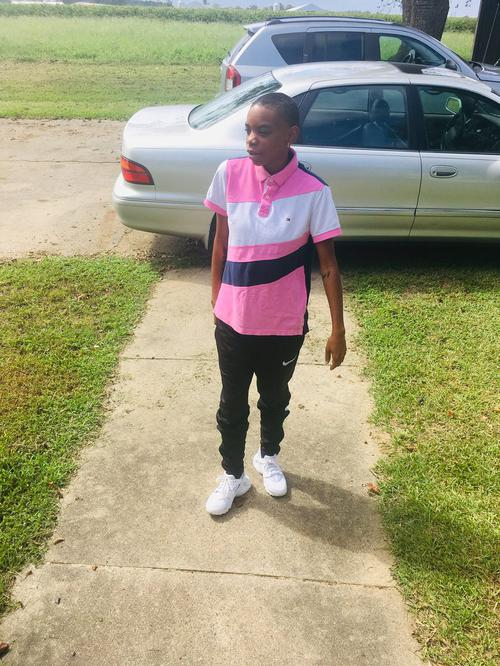

In [ ]:
# Example 1
display(data_captioned[data_captioned['file_id'] == image1])
display_image(zip_path, image_dir, image1)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption
24498,1105179456652656640,http://pbs.twimg.com/media/D1Zi2FcWoAAuWiE.jpg,"[0, 0, 3]",https://twitter.com/user/status/1105179456652656640,He's just a gay cunt. Such a fuckin gay cunt. https://t.co/OKJ2eVNthQ,"[NotHate, NotHate, Homophobe]",2019-03-11 18:51:30.364,,a cartoon of a man with glasses on


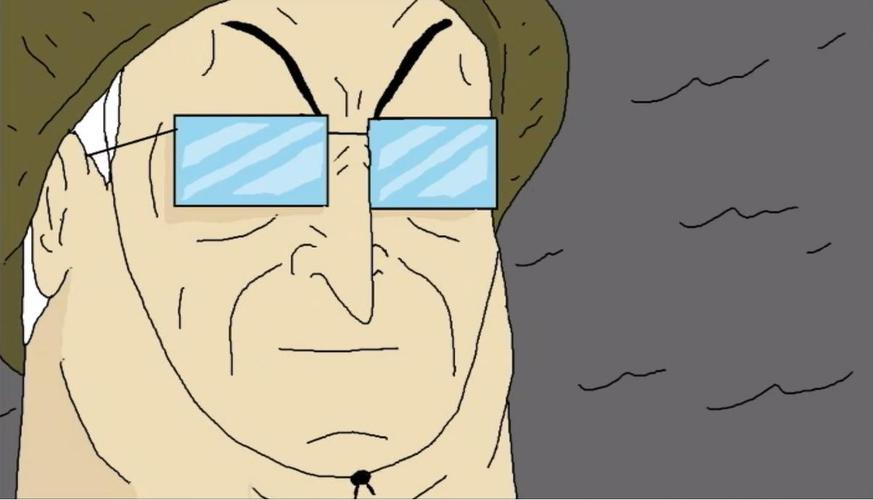

In [ ]:
# Example 2
display(data_captioned[data_captioned['file_id'] == image2])
display_image(zip_path, image_dir, image2)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption
105440,1055190311352352768,http://pbs.twimg.com/media/DqTJ-_UWoAAJbeI.jpg,"[0, 5, 3]",https://twitter.com/user/status/1055190311352352768,@politico Also spread by SCOTUS justice Thomas’ wife a tea party conspiracy theorist @GinniThomas https://t.co/7Bktos6Nak,"[NotHate, OtherHate, Homophobe]",2018-10-24 20:12:29.371,"Ginni Thomas 2 days ago The media won't share THIS, will they? It is an invasion, and thank GOD for President Trump.",a man in a black jacket and a red face is holding a knife


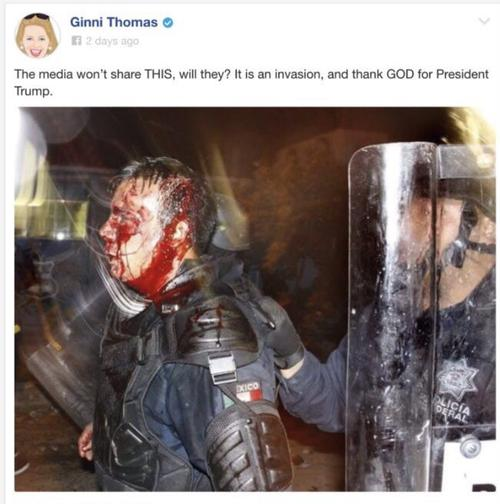

In [ ]:
# Example 3
display(data_captioned[data_captioned['file_id'] == image3])
display_image(zip_path, image_dir, image3)